# Questionnaire Analysis: Transparency, Trust & Mental Model (F1 / F2 / F3)

OpenMATB transparency study -- the post-block and final questionnaires. Tests
**H1** and **H2** (the main hypothesis pair) plus the final preference debrief.

- **H1 -- subjective transparency & trust favour the verbose form.** Participants
  rate the verbose always-on explanation (F1) as more transparent and more
  trustworthy than the selective forms (F2/F3), even though action-relevant
  content is held constant.
- **H2 -- form modulates explicability.** Participants achieve higher post-block
  **mental-model accuracy** under the selective/contrastive forms (F2/F3) than
  under F1, even with content held constant.

Together H1 + H2 instantiate the explainability != explicability crossover:
feeling informed (F1) can diverge from actually understanding the aid (F2/F3).

> **Status:** pipeline prepared on pilot data; re-run unchanged once P01-P20 are collected.

## What is measured (after each block; logged by genericscales)

- **Subjective transparency (H1):** "told me what it was doing" and "made clear
  which indicator to attend to next" (1-7, higher = more transparent), reported as
  their mean. The third item, "amount of information felt about right"
  (far-too-little <-> far-too-much), is **not** monotone, so it is reported
  separately as a *miscalibration* = |rating - 4| (0 = ideal).
- **Subjective trust (H1):** four items (reliable / does-what-I-expect /
  confident / can-trust), 1-7, mean.
- **Mental-model probe (H2):** yes/no "did the aid act on indicator X" items,
  a miss-count slider, and a reliability slider, scored against ground truth
  (the aid acts on exactly that block's two gauges; 2 misses/block; ~78%
  reliability). Reported as set-identification accuracy, |miss-count error|,
  |reliability error|, and a normalised composite **explicability** score (0-1).
- **Preference debrief (final, once):** five forced F1<->F3 choices.

## Literature

Transparency as levels of agent information: SAT model (Chen et al., 2014;
Mercado et al., 2016; Stowers et al., 2017). Explanation quality and the
explainability/explicability distinction: Miller (2019); the dissociation between
feeling informed and understanding: Wang & Yin (2021), Bansal et al. (2021).
Subjective trust items adapt the trust-in-automation tradition (Jian et al., 2000;
Madsen & Gregor, 2000).


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table, build_debrief_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)


## 1. Load sessions and questionnaire metrics

In [2]:
sessions = find_study_sessions()
print(f"Reading logs from: {DEFAULT_SESSIONS_DIR}")
print(f"Discovered {len(sessions)} study session(s).")
if not sessions:
    print("No logs yet. Copy the relevant OpenMATB session CSVs into")
    print("analysis/session_logs/ and re-run this notebook.")

table = build_metrics_table(sessions)
q_cols = ["subj_transparency", "info_volume", "info_volume_miscal", "subj_trust",
          "mm_set_accuracy", "mm_skipped_error", "mm_reliability_error", "mm_explicability"]
table[["participant", "form", "block"] + q_cols].round(2)


Reading logs from: C:\Projects\HumanCenteredAI\analysis\session_logs
Discovered 1 study session(s).


,participant,form,block,subj_transparency,info_volume,info_volume_miscal,subj_trust,mm_set_accuracy,mm_skipped_error,mm_reliability_error,mm_explicability
0,P02,F1,A,7.00,7.00,3.00,7.00,1.00,0.19,3.34,0.98
1,P02,F3,B,4.74,4.02,0.02,6.98,0.75,0.95,38.38,0.71
2,P02,F2,C,4.52,2.45,1.55,7.00,0.50,1.18,6.37,0.75


## 1b. Session validation

Cross-check each session against the study design before trusting its numbers.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with issues.")
report


1 session(s) validated; 0 with issues.


,session_file,participant,kind,ok,n_blocks,realized,expected,issues
0,24_260530_151227.csv,P02,full,True,3,"[(F1, A), (F3, B), (F2, C)]","[(F1, A), (F3, B), (F2, C)]",


## 2. H1 -- Subjective transparency & trust by form

H1 predicts F1 > F2/F3 on both (higher = more transparent / more trusted).

In [4]:
h1_cols = ["subj_transparency", "subj_trust", "info_volume_miscal"]
h1_desc = table.groupby("form")[h1_cols].agg(["mean", "median", "std"]).reindex(FORM_ORDER)
h1_desc.round(2)


subj_transparency            subj_trust            info_volume_miscal  \
                  mean median std       mean median std               mean   
form                                                                         
F1                7.00   7.00 NaN       7.00   7.00 NaN               3.00   
F2                4.52   4.52 NaN       7.00   7.00 NaN               1.55   
F3                4.74   4.74 NaN       6.98   6.98 NaN               0.02   

                 
     median std  
form             
F1     3.00 NaN  
F2     1.55 NaN  
F3     0.02 NaN

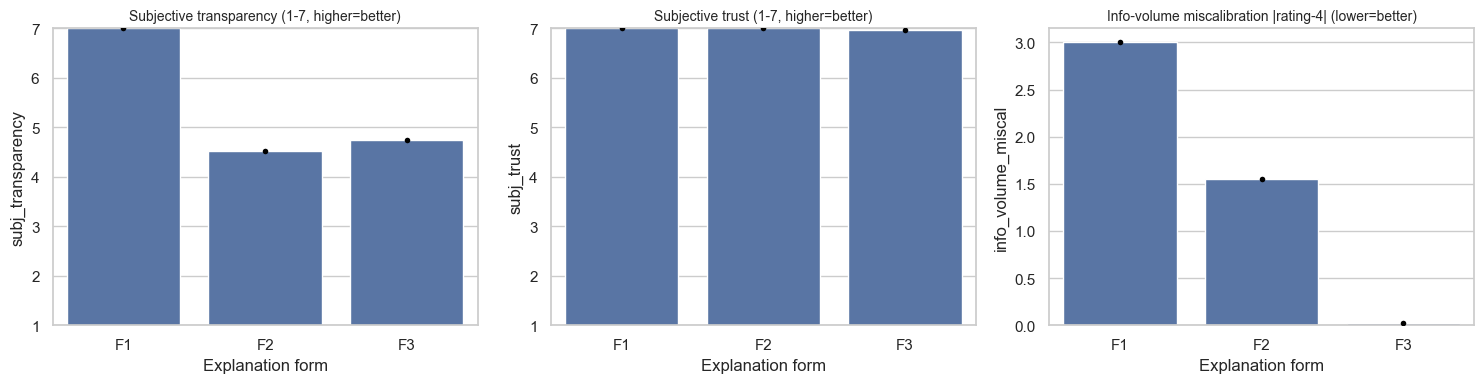

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
specs = [("subj_transparency", "Subjective transparency (1-7, higher=better)"),
         ("subj_trust", "Subjective trust (1-7, higher=better)"),
         ("info_volume_miscal", "Info-volume miscalibration |rating-4| (lower=better)")]
for ax, (col, title) in zip(axes, specs):
    sns.barplot(data=table, x="form", y=col, order=FORM_ORDER, errorbar="sd", ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER, color="black", size=4, ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Explanation form")
for ax in axes[:2]:
    ax.set_ylim(1, 7)
fig.tight_layout()
fig.savefig(OUT / "h1_transparency_trust_by_form.png", dpi=150)
plt.show()


## 3. H2 -- Mental-model accuracy (explicability) by form

H2 predicts F2/F3 > F1 on accuracy/explicability (higher = better) and F2/F3 < F1
on the error measures (lower = better).

In [6]:
h2_cols = ["mm_set_accuracy", "mm_explicability", "mm_skipped_error", "mm_reliability_error"]
h2_desc = table.groupby("form")[h2_cols].agg(["mean", "median", "std"]).reindex(FORM_ORDER)
h2_desc.round(2)


mm_set_accuracy            mm_explicability            mm_skipped_error  \
                mean median std             mean median std             mean   
form                                                                           
F1              1.00   1.00 NaN             0.98   0.98 NaN             0.19   
F2              0.50   0.50 NaN             0.75   0.75 NaN             1.18   
F3              0.75   0.75 NaN             0.71   0.71 NaN             0.95   

                mm_reliability_error             
     median std                 mean median std  
form                                             
F1     0.19 NaN                 3.34   3.34 NaN  
F2     1.18 NaN                 6.37   6.37 NaN  
F3     0.95 NaN                38.38  38.38 NaN

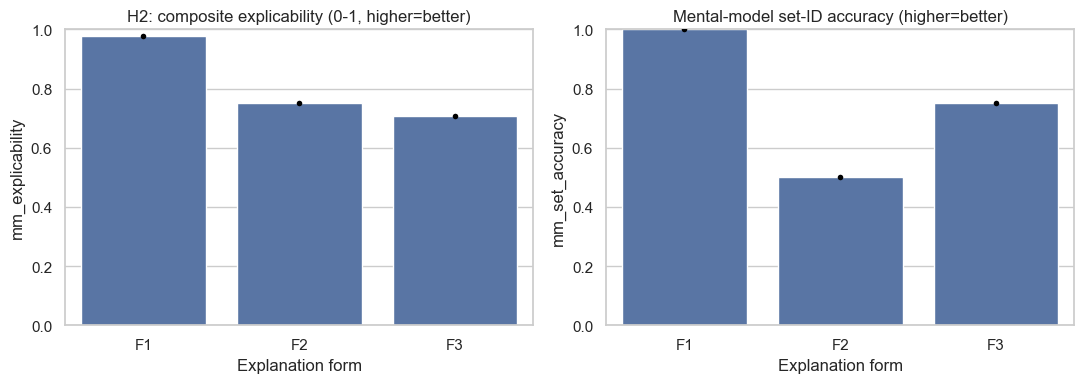

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["mm_explicability", "mm_set_accuracy"],
    ["H2: composite explicability (0-1, higher=better)",
     "Mental-model set-ID accuracy (higher=better)"],
):
    sns.barplot(data=table, x="form", y=col, order=FORM_ORDER, errorbar="sd", ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER, color="black", size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Explanation form")
    ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(OUT / "h2_explicability_by_form.png", dpi=150)
plt.show()


## 4. Final preference debrief

Five forced choices on a 1 = Form 1 (continuous) <-> 7 = Form 3 (selective + cue)
scale, one row per participant. Mean > 4 leans toward F3, < 4 toward F1.

,participant,session_file,PREF_q1_most_informative,PREF_q2_most_useful,PREF_q3_most_trusted,PREF_q4_least_distracting,PREF_q5_self_chosen
0,P02,24_260530_151227.csv,1.01,7.0,7.0,4.0,4.0


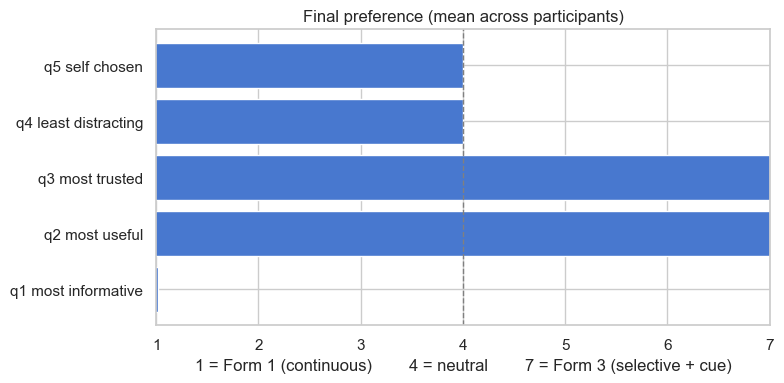

In [8]:
debrief = build_debrief_table(sessions)
pref_cols = ["PREF_q1_most_informative", "PREF_q2_most_useful", "PREF_q3_most_trusted",
             "PREF_q4_least_distracting", "PREF_q5_self_chosen"]
display(debrief.round(2))

if not debrief.empty:
    means = debrief[pref_cols].mean()
    fig, ax = plt.subplots(figsize=(8, 4))
    labels = [c.replace("PREF_", "").replace("_", " ") for c in pref_cols]
    ax.barh(labels, means.values, color="#4878CF")
    ax.axvline(4, color="grey", ls="--", lw=1)
    ax.set_xlim(1, 7)
    ax.set_xlabel("1 = Form 1 (continuous)        4 = neutral        7 = Form 3 (selective + cue)")
    ax.set_title("Final preference (mean across participants)")
    fig.tight_layout()
    fig.savefig(OUT / "debrief_preferences.png", dpi=150)
    plt.show()


## 5. Summary (H1 + H2) and the explainability != explicability crossover

The crossover prediction: F1 wins on *felt* transparency/trust (H1) while F2/F3
win on *actual* understanding (H2).

In [9]:
summary = (table.groupby("form")[
              ["subj_transparency", "subj_trust", "mm_set_accuracy", "mm_explicability"]]
              .mean().reindex(FORM_ORDER).round(2))
summary.to_csv(OUT / "h1_h2_summary_by_form.csv")
summary


,subj_transparency,subj_trust,mm_set_accuracy,mm_explicability
form,,,,
F1,7.00,7.00,1.00,0.98
F2,4.52,7.00,0.50,0.75
F3,4.74,6.98,0.75,0.71


## 6. Inferential tests -- to add when N is adequate

Deliberately omitted now (small pilot N). When P01-P20 are collected, add
within-subject tests across the three forms per measure (e.g. Friedman omnibus +
Wilcoxon signed-rank post-hoc), and test the H1xH2 crossover explicitly. The tidy
table above is the input.
